In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from uncertainties import unumpy
from uncertainties import ufloat
import warnings
warnings.filterwarnings('ignore')

from matplotlib.patches import Circle

from astropy.coordinates import SkyCoord
import astropy.units as u

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 16}
font_cb = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}


In [3]:
def frac_bin(df):
    if len(df)<15:
        return np.nan
    else:
        total_sistemas = len(df)
        
        num_binarias = len(df[df['comp_mass'] > 0])
        return num_binarias/total_sistemas
    
data = pd.read_csv('data.csv', index_col='Cluster')
df = pd.read_csv('log-results-eDR3-MF_integrada.csv', index_col='Cluster')

In [4]:
df['X'] = df['dist']*np.cos(df['RA_ICRS'])*np.cos(df['DE_ICRS'])
df['Y'] = df['dist']*np.sin(df['RA_ICRS'])*np.cos(df['DE_ICRS'])
df['Z'] = df['dist']*np.sin(df['DE_ICRS'])

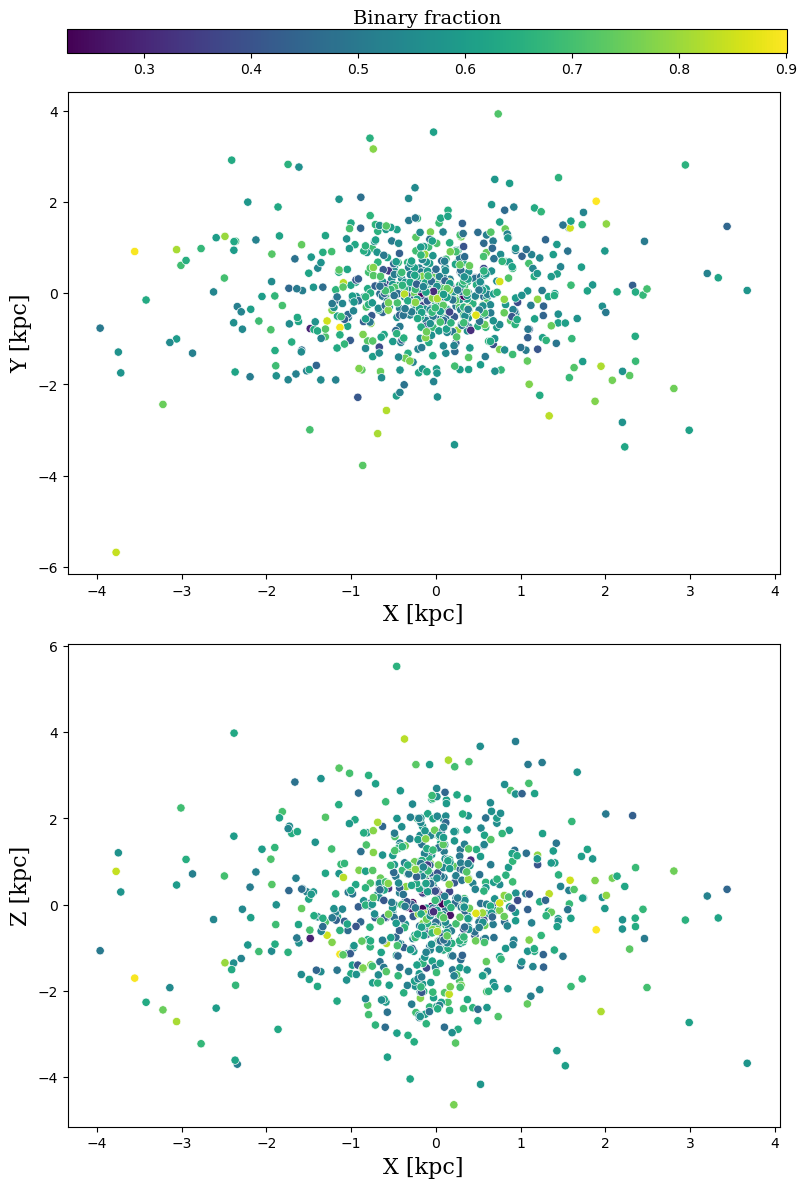

In [43]:
fig, ax = plt.subplots(2,1, figsize=(8, 12))


# Scatter plot
sns.scatterplot(data=df, x='X', y='Y', hue='bin_frac', palette=palette, legend=None, ax=ax[0], )
sns.scatterplot(data=df, x='X',y='Z', hue='bin_frac', palette=palette, legend=None, ax =ax[1])


#plt.axvline(0, color='r',ls='--',alpha=0.5)
#plt.axhline(0, color='r',ls='--',alpha=0.5)


cbar_ax = fig.add_axes([0.09, .95, .9, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.ax.xaxis.set_label_position('top')
cbar.set_ticks(np.arange(0.3, df.bin_frac.max(), 0.1).round(1))
cbar.set_label('Binary fraction', fontdict=font_cb)


ax[0].set_ylabel(r'Y [kpc]', fontdict=font)
ax[0].set_xlabel(r'X [kpc]', fontdict=font)

ax[1].set_ylabel(r'Z [kpc]', fontdict=font)
ax[1].set_xlabel(r'X [kpc]', fontdict=font)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('distribuição_espacial_aglomerados.png',bbox_inches='tight', dpi=300)
plt.show()



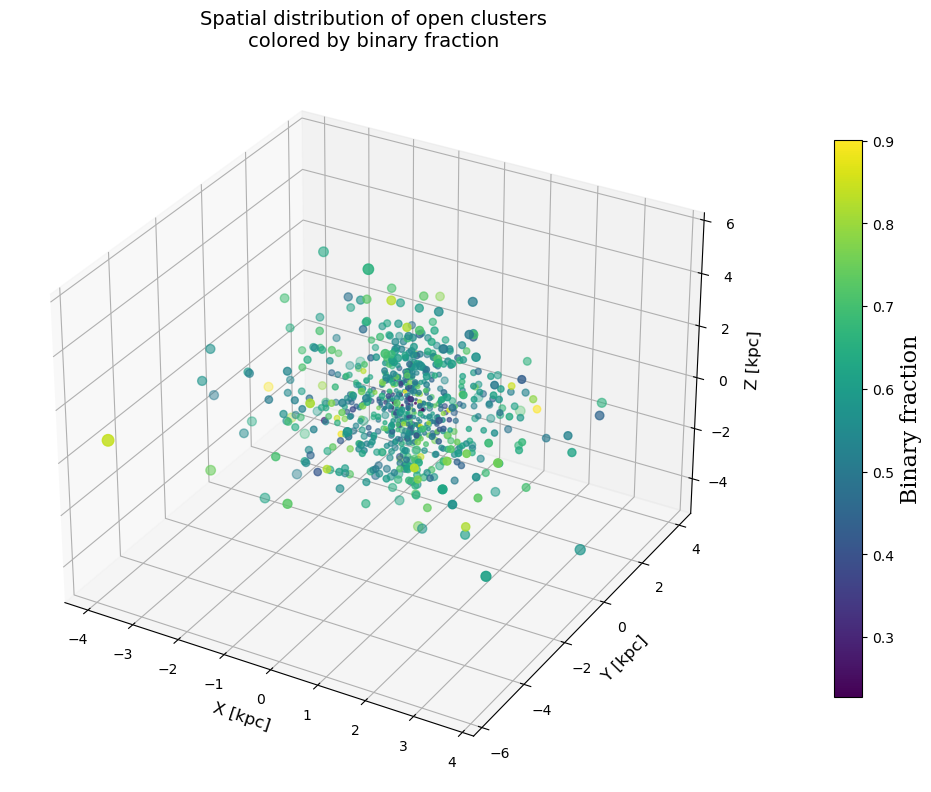

In [68]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np

# Figura e eixo 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df['X']
y = df['Y']
z = df['Z']
c = df['bin_frac']

norm = plt.Normalize(c.min(), c.max())
colors = plt.cm.viridis(norm(c)) 

# Gráfico de dispersão 3D
#ax.scatter(0, 0, 0, color='red', marker='*', s=200, label='Sun')
scatter = ax.scatter(x, y, z, c=c, cmap=palette, s=10*df.dist)

# Marcar o Sol no centro


# Eixos
ax.set_xlabel('X [kpc]', fontsize=12)
ax.set_ylabel('Y [kpc]', fontsize=12)
ax.set_zlabel('Z [kpc]', fontsize=12)

# Barra de cor
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.75)
cbar.set_label('Binary fraction', fontdict=font)
cbar.ax.tick_params(labelsize=10)

# Título (opcional)
ax.set_title('Spatial distribution of open clusters\ncolored by binary fraction', fontsize=14)

# Mostrar
plt.tight_layout()
plt.show()


In [59]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='X', y='Y', z='Z',
    color='bin_frac',
    color_continuous_scale='viridis',
    labels={'bin_frac': 'Binary fraction'},
    title='3D Distribution of Open Clusters'
)

# Adiciona ponto para o Sol
fig.add_scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=5, color='red', symbol='square'),
    name='Sun'
)

fig.show()


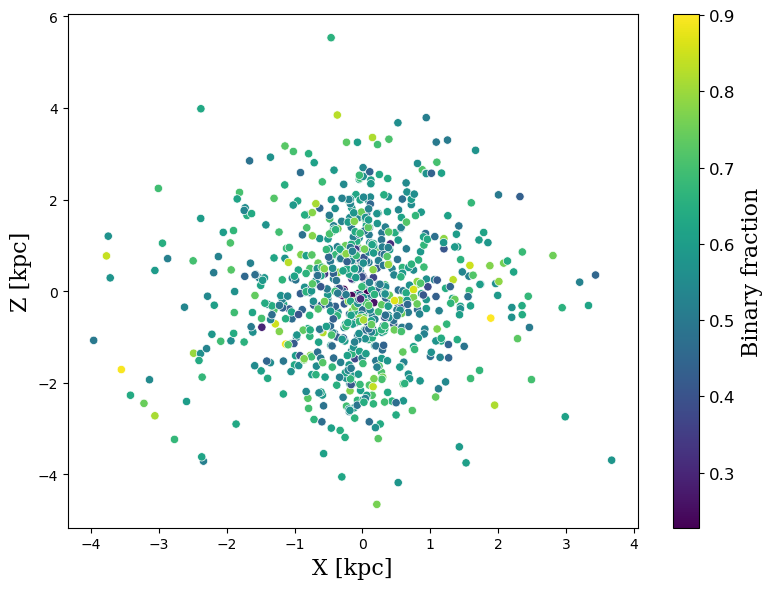

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot
sns.scatterplot(
    data=df, x='X', y='Z',
    hue='bin_frac',
    palette=palette,
    legend=False,
    ax=ax
)

# Barra de cor
norm = plt.Normalize(df.bin_frac.min(), df.bin_frac.max())
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Binary fraction', fontdict=font)
cbar.ax.tick_params(labelsize=12)

# Rótulos dos eixos
ax.set_xlabel(r'X [kpc]', fontdict=font)
ax.set_ylabel(r'Z [kpc]', fontdict=font)

# Título ou legenda, se quiser
# ax.legend()

plt.tight_layout()
plt.show()


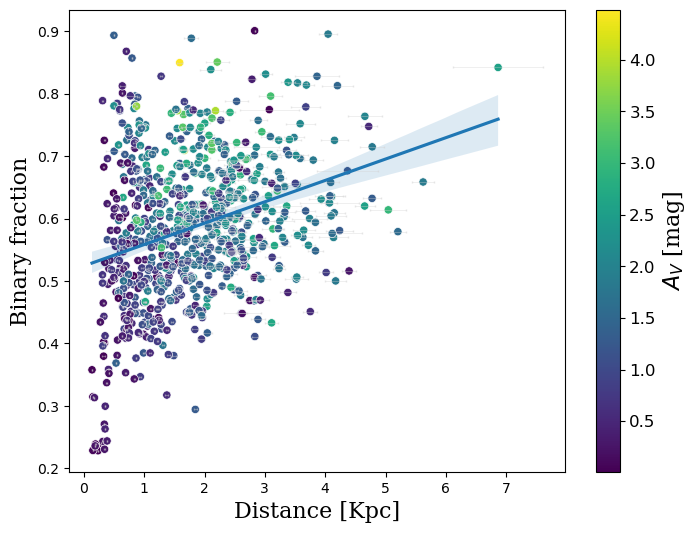

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='dist', y= 'bin_frac', hue='Av', palette=palette, legend=None)




plt.errorbar(df.dist, df.bin_frac, yerr= df.e_dist,
             fmt='none', ecolor='lightgray', elinewidth=.5, capsize=.5, alpha=.5
)
sns.regplot(data=df, x='dist', y='bin_frac', scatter=False, )

norm = plt.Normalize(df.Av.min(), vmax=df.Av.max()) 
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])  
cbar = plt.colorbar(sm)
cbar.set_label(r'$A_V$ [mag]', fontdict=font)
cbar.ax.tick_params(labelsize=12) 

plt.xlabel('Distance [Kpc]', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)
plt.savefig('dist_fb_dist_Av.png',bbox_inches='tight', dpi=300)
plt.show()



In [97]:
data

,pmRApmDEcor,PlxpmRAcor,PlxpmDEcor,RA_ICRS,e_RA_ICRS,DE_ICRS,e_DE_ICRS,Plx,e_Plx,pmRA,...,alpha_high_int,alpha_high_er_int,alpha_low_int,alpha_low_er_int,Mc_int,Mc_er_int,offset_int,offset_er_int,q,er_q
Cluster,,,,,,,,,,,,,,,,,,,,,
ASCC_10,0.3947,0.2452,0.3009,51.878597,0.0382,34.373353,0.0302,1.5327,0.0431,-1.743,...,-1.35456,0.48142,1.25945,0.31552,-0.10962,0.06576,1.40198,0.09958,0.000000,0.000000
ASCC_10,0.0225,0.1502,0.2691,51.655044,0.0646,34.830793,0.0464,1.5148,0.0751,-1.671,...,-1.35456,0.48142,1.25945,0.31552,-0.10962,0.06576,1.40198,0.09958,0.000000,0.017435
ASCC_10,0.1962,0.0973,0.1962,51.562305,0.0183,35.038219,0.0152,1.6062,0.0227,-1.759,...,-1.35456,0.48142,1.25945,0.31552,-0.10962,0.06576,1.40198,0.09958,0.000000,0.100508
ASCC_10,-0.2873,-0.0543,0.3951,51.669998,0.1343,34.751452,0.1017,1.5993,0.1523,-1.613,...,-1.35456,0.48142,1.25945,0.31552,-0.10962,0.06576,1.40198,0.09958,0.847118,0.059452
ASCC_10,0.3337,0.2404,0.2745,52.247907,0.0164,35.100717,0.0130,1.5441,0.0195,-1.705,...,-1.35456,0.48142,1.25945,0.31552,-0.10962,0.06576,1.40198,0.09958,0.187037,0.221100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
vdBergh_92,-0.0501,0.1582,0.0278,106.005495,0.0761,-11.604856,0.0820,0.9346,0.0905,-4.379,...,-1.46781,0.15596,1.96815,0.25251,-0.20000,0.02492,1.71558,0.04529,0.000000,0.000000
vdBergh_92,-0.1744,-0.0782,0.0656,106.083301,0.0667,-11.372899,0.0733,0.9971,0.0824,-4.507,...,-1.46781,0.15596,1.96815,0.25251,-0.20000,0.02492,1.71558,0.04529,0.000000,0.124435
vdBergh_92,-0.2079,0.1070,0.2052,106.166213,0.2012,-11.472170,0.2035,0.8268,0.2374,-4.409,...,-1.46781,0.15596,1.96815,0.25251,-0.20000,0.02492,1.71558,0.04529,0.000000,0.155791
